In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from hostrada4py import hostradaPoint as hp
from hostrada4py import hostrada_HeatPeriodsGermany as hhp

import os
os.environ["HOSTRADA_NETCDF_SUBSET_MODE"] = "full"
#os.environ["HOSTRADA_NETCDF_SUBSET_MODE"] = "auto"

## The following table shows the 20 hottest climate periods in Germany between 1995 and June 2026

| Rank| Core phase of the heat wave|  Max. temperature  | Station                          | Latitude    |                          Longitude |
| --: | -------------------------- | -----------------: | -------------------------------- | ----------: | ---------------------------------: |
|   1 | 22.–26.07.2019             |            41,2 °C | Duisburg-Baerl                   |  51,5088 °N |     6,7018 °E ([meteostat.net][1]) ||
|   2 | 30.06.–06.07.2015          |            40,3 °C | Kitzingen                        |  49,7363 °N |    10,1781 °E ([meteostat.net][3]) |
|   3 | 03.–08.08.2015             |            40,3 °C | Kitzingen                        |  49,7363 °N |    10,1781 °E ([meteostat.net][3]) |
|   4 | 01.–13.08.2003             |            40,2 °C | Karlsruhe                        |  49,0333 °N |     8,3667 °E ([meteostat.net][4]) |
|   5 | 17.–20.07.2022             |            40,1 °C | Hamburg-Neuwiedenthal            |  53,4777 °N |     9,8957 °E ([meteostat.net][5]) |
|   6 | 17.–21.08.2012             |            39,8 °C | Dresden-Hosterwitz               |  51,0221 °N |    13,8470 °E ([meteostat.net][6]) |
|   7 | 24.–30.06.2019             |            39,6 °C | Bernburg/Saale (Nord)            |  51,8218 °N |    11,7109 °E ([meteostat.net][7]) |
|   8 | 23.07.–08.08.2018          |            39,5 °C | Bernburg/Saale (Nord)            |  51,8218 °N |    11,7109 °E ([meteostat.net][7]) |
|   9 | 28.06.–03.07.2025          |            39,3 °C | Andernach                        |  50,4237 °N |     7,4202 °E ([meteostat.net][8]) |
|  10 | 12.–16.07.2007             |            39,2 °C | Holzdorf / Fliegerhorst Holzdorf |  51,7667 °N |    13,1833 °E ([meteostat.net][9]) |
|  11 | 15.–19.06.2022             |            39,2 °C | Dresden-Strehlen                 |  51,0248 °N |   13,7750 °E ([meteostat.net][10]) |
|  12 | 09.–27.07.2006             |            38,9 °C | Bernburg/Saale (Nord)            |  51,8218 °N |    11,7109 °E ([meteostat.net][7]) |
|  13 | 03.–21.07.2010             |            38,8 °C | Bendorf                          |  50,4167 °N |    7,5833 °E ([meteostat.net][11]) |
|  14 | 08.–17.07.2023             |            38,8 °C | Möhrendorf-Kleinseebach          |  49,6497 °N |   11,0074 °E ([meteostat.net][12]) |
|  15 | 25.–29.07.2013             |            38,6 °C | Rheinfelden                      |  47,5590 °N | 7,7721 °E ([Climate Explorer][13]) |
|  16 | 07.–11.08.2020             |            38,6 °C | Trier-Petrisberg                 |  49,7500 °N |    6,6667 °E ([meteostat.net][14]) |
|  17 | 18.06.2026–laufend*        | mindestens 38,5 °C | Kitzingen                        |  49,7363 °N |    10,1781 °E ([meteostat.net][3]) |
|  18 | 24.–28.08.2016             |            37,9 °C | Saarbrücken-Burbach              |  49,2406 °N |    6,9351 °E ([meteostat.net][15]) |
|  19 | 06.–10.06.2014             |            37,7 °C | Rheinau-Memprechtshofen          |  48,6703 °N |    7,9939 °E ([meteostat.net][16]) |
|  20 | 19.–23.06.2017             |            37,2 °C | Trier-Petrisberg                 |  49,7500 °N |    6,6667 °E ([meteostat.net][14]) |

The coordinates refer to the stations themselves, not to the geographic centers of the respective cities or municipalities. The DWD Open Data station metadata includes the fields `geoBreite` and `geoLaenge` for this purpose; for older or relocated stations, the coordinates of the measurement site documented in the respective time series apply. ([opendata.dwd.de][17])

[1]: https://meteostat.net/de/station/D3670? "Duisburg-Baerl | Wetterrückblick & Klimadaten"
[3]: https://meteostat.net/de/station/D2600? "Kitzingen | Wetterrückblick & Klimadaten"
[4]: https://meteostat.net/de/station/10727? "Karlsruhe | Wetterrückblick & Klimadaten"
[5]: https://meteostat.net/de/station/D1981? "Hamburg-Neuwiedenthal | Wetterrückblick & Klimadaten"
[6]: https://meteostat.net/de/station/D1050? "Dresden-Hosterwitz | Wetterrückblick & Klimadaten"
[7]: https://meteostat.net/de/station/D0445? "Bernburg / Saale (Nord) | Wetterrückblick & Klimadaten"
[8]: https://meteostat.net/de/station/D0161 "Andernach | Wetterrückblick & Klimadaten | Meteostat"
[9]: https://meteostat.net/de/station/10476? "Holzdorf | Wetterrückblick & Klimadaten"
[10]: https://meteostat.net/de/station/D1051? "Dresden-Strehlen | Wetterrückblick & Klimadaten"
[11]: https://meteostat.net/de/station/10515? "Bendorf | Wetterrückblick & Klimadaten | Meteostat"
[12]: https://meteostat.net/de/station/D1279? "Möhrendorf-Kleinseebach | Wetterrückblick & Klimadaten | Meteostat"
[13]: https://climateexplorer.app/dwd/hourly/baden-wuerttemberg/rheinfelden/? "Rheinfelden, Baden-Württemberg – Hourly Climate Data | DWD ..."
[14]: https://meteostat.net/de/station/10609? "Trier-Petrisberg | Wetterrückblick & Klimadaten"
[15]: https://meteostat.net/de/station/D6217? "Saarbrücken-Burbach | Wetterrückblick & Klimadaten"
[16]: https://meteostat.net/de/station/D4169? "Rheinau-Memprechtshofen | Wetterrückblick & Klimadaten"
[17]: https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/KL_Tageswerte_Beschreibung_Stationen.txt "opendata.dwd.de"


## Visualisation of one of these hottest climate periods

In [108]:
rank = 1

start_UTC = hhp.heat_periods_germany["events"][rank-1]["core_period"]["start"]
end_UTC = hhp.heat_periods_germany["events"][rank-1]["core_period"]["end"]
location = hhp.heat_periods_germany["events"][rank-1]["measurement_sites"][0]["name"]
meteostation = hhp.heat_periods_germany["events"][rank-1]["measurement_sites"][0]["source_url"]
lon = hhp.heat_periods_germany["events"][rank-1]["measurement_sites"][0]["longitude"]
lat = hhp.heat_periods_germany["events"][rank-1]["measurement_sites"][0]["latitude"]

df = hp.extract_values_for_point(
    var= 'tas',
    lon=lon,
    lat=lat,
    start=start_UTC,
    end=end_UTC
)

fn = "HOSTRADA_tas.csv"
df.to_csv(fn, index=False)
print(f"{len(df)} rows written to {fn}.")

Cache: hostrada_cache/tas_1hr_HOSTRADA-v1-0_BE_gn_2019070100-2019073123.nc
Read: hostrada_cache/tas_1hr_HOSTRADA-v1-0_BE_gn_2019070100-2019073123.nc
97 rows written to HOSTRADA_tas.csv.


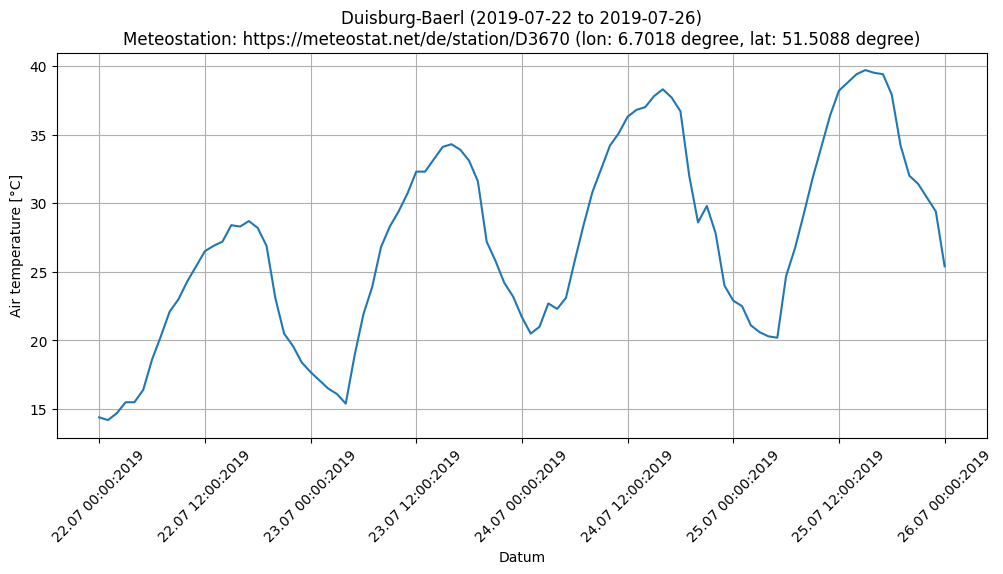

In [109]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["time"], df['tas'])
ax.set_xlabel("Datum")
ax.set_ylabel("Air temperature [°C]")


title = location + " (" + str(start_UTC) + " to " + str(end_UTC) + ")\n" + "Meteostation: " + meteostation + " (lon: " + str(lon) + " degree, lat: " + str(lat) + " degree)"

ax.set_title(title)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M:%Y"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.grid(True)
plt.show()